# Universidade Federal de São João del-Rei

# Machine Learning Aplicado à Engenharia

# Trabalho 2 (T2) — Modelagem, Validação e Comparação de Modelos de Aprendizado de Máquina

**Tema:** Análise Exploratória de Sinais EEG para Monitoramento e Classificação de Estados de Sono em Janelas de 30 Segundos

**Base utilizada:** _Sleep-EDF Database Expanded_

**Fonte:** https://www.physionet.org/content/sleep-edfx/1.0.0/

# Referência da Base

- B Kemp, AH Zwinderman, B Tuk, HAC Kamphuisen, JJL Oberyé. _Analysis of a sleep-dependent neuronal feedback loop: the slow-wave microcontinuity of the EEG_. IEEE-BME 47(9):1185-1194 (2000).

# Citação Padrão para PhysioNet

- Goldberger, A., Amaral, L., Glass, L., Hausdorff, J., Ivanov, PC, Mark, R., ... & Stanley, HE (2000). PhysioBank, PhysioToolkit, and PhysioNet: Components of a new research resource for complex physiologic signals. Circulation [Online]. 101 (23), pp. e215–e220. RRID:SCR_007345.

**Integrantes do grupo:**
- Ícaro Ferreira dos Santos
- Wendell Christian Calixto Pinto
- Gabriel Augusto Silva Batista

**Repositório do grupo:**  
https://github.com/gabrielbtt/analise-estados-sono-eeg

# Convenção de Cores para Identificar Contribuições
- <font color="blue">Azul:</font> Ícaro Ferreira dos Santos
- <font color="green">Verde:</font> Wendell Christian Calixto Pinto
- <font color="red">Vermelho:</font> Gabriel Augusto Silva Batista

# Definição do Problema <font color="blue">(Ícaro)</font>

O problema escolhido neste trabalho consiste na **classificação automática dos estágios do sono** a partir de sinais de EEG do canal Fpz-Cz. A análise manual de polissonografias é um processo demorado, subjetivo e altamente dependente da experiência do técnico. Um sistema automatizado torna o diagnóstico mais rápido, objetivo e acessível, reduzindo a variabilidade entre profissionais.

Trata-se de um **problema de classificação supervisionada multiclasse**, cuja variável alvo (`y`) é a coluna `id_estagio`, derivada da coluna `estagio`, contendo cinco categorias discretas: Vigília (W), N1, N2, N3 (sono profundo) e REM.

As variáveis de entrada (atributos `X`) são compostas por características extraídas de cada época de 30 segundos, divididas em dois grupos principais:
- Características Estatísticas: média, desvio padrão, variância, valor RMS, assimetria e curtose da amplitude do sinal;
- Características Espectrais: potência absoluta e relativa nas bandas Delta (0,5-4 Hz), Theta (4-8 Hz), Alpha (8-13 Hz) e Beta (13-30 Hz), além de razões espectrais (como Delta/Alpha e Delta/Theta).

Essas variáveis foram selecionadas porque capturam propriedades fisiológicas críticas dos estágios do sono. A **potência delta** discrimina o sono profundo (N3), o **valor RMS** reflete a energia total do sinal em cada época, e a **assimetria** ajuda a identificar a instabilidade característica da vigília e do sono leve.

Apesar dos avanços, a base apresenta algumas limitações importantes: o estágio N2 é predominante (42,43% das épocas), enquanto o N1 é raro (8,03%), o que pode enviesar o modelo. Além disso, estágios fisiologicamente próximos, como N1 e REM, apresentam assinaturas estatísticas semelhantes, dificultando a definição de fronteiras de decisão. Por fim, diferenças individuais entre pacientes podem afetar a capacidade de generalização do modelo.


# Descrição da Base de Dados

A base utilizada é a *Sleep-EDF Database Expanded*, obtida via [PhysioNet](https://www.physionet.org/content/sleep-edfx/1.0.0/). Trata-se de um conjunto de dados reais de polissonografia voltado para o estudo da arquitetura do sono.

Os dados dos sinais polissonográficos (arquivos com extensão .PSG.edf) estão no formato EDF (*European Data Format*), contendo EEG (eletrodos Fpz-Cz e Pz-Oz), EOG (horizontal), EMG submentoniano, um marcador de evento e, geralmente, também sinais de respiração oronasal e temperatura corporal retal. Os hipnogramas, anotações dos estágios do sono, armazenados em arquivos com extensão *.Hypnogram.edf, estão no formato EDF+. Os arquivos são nomeados no padrão SC4 ssN EO-PSG.edf, em que "ss" corresponde ao número do sujeito e "N" é noite de coleta.

> **Sinais Utilizados:** Foram extraídas características do canal de EEG Fpz-Cz, com frequência de amostragem de 100 Hz.

> Os hipnogramas foram anotados manualmente por técnicos treinados seguindo o padrão Rechtschaffen & Kales, dividindo o registro em épocas de 30 segundos.

Além disso, problema consiste em uma classificação multiclasse com 5 categorias discretas:

- W (Vigília): momento em que a pessoa está acordada ou quase acordando;
- N1: sono leve de transição (fácil de acordar);
- N2: sono mais estável, que ocupa a maior parte da noite;
- N3: sono profundo, importante para recuperação física do corpo;
- R (REM): sono dos sonhos, essencial para a memória e o equilíbrio emocional.

**Escopo do Trabalho**

Para este trabalho, foram utilizados 20 pares de arquivos do banco Sleep-EDF Expanded, do registro `SC4001E` ao `SC4092E`. Essa expansão permite treinar o modelo com um volume significativamente maior de épocas em comparação ao estudo exploratório inicial, que utilizou apenas uma noite de um único paciente.

A base consolidada (`dados_epocas.csv`) possui 21.039 épocas de 30 segundos e foi gerada a partir dos arquivos EDF por meio da biblioteca MNE. Para o SVM, a separação entre treino e teste é feita por noite (`chavepar`), de forma a avaliar melhor a capacidade de generalização para registros não vistos.


# Conclusões do T1 e Motivação para o T2

A análise exploratória realizada no T1 consolidou a base `Sleep-EDF Expanded` como um conjunto de dados estruturado e tecnicamente justificado para tarefas de aprendizado de máquina. As principais conclusões que motivam este Trabalho 2 são:

- A **Potência Delta** é a característica mais robusta para distinguir o sono profundo (N3), com valores superiores aos estágios de sono leve.
- O valor **RMS** validou a realidade biológica do sono, sendo mais elevado no estágio N3 devido à grande amplitude das ondas lentas.
- A segmentação dos sinais brutos em épocas de 30 segundos transforma registros longos de EEG em amostras compactas e interpretáveis. No T2, a base consolidada passou a reunir **21.039 épocas** de 20 noites, tornando o conjunto mais adequado à aplicação de modelos de classificação multiclasse.

Embora o sono seja um processo cíclico e sequencial, no qual cada estágio é influenciado pelo anterior, como evidenciado pelo hipnograma no T1, o objetivo deste trabalho é realizar uma classificação multiclasse baseada nas características extraídas individualmente de cada época de 30 segundos (tais como valor RMS e potência nas bandas de frequência).

Dessa forma, cada janela de 30 segundos é tratada como uma amostra independente para o classificador. Essa abordagem justifica a concatenação dos dados de todas as noites e pacientes em um único *DataFrame* para treinamento. No entanto, devido à natureza temporal inerente ao sono, dois cuidados críticos devem ser observados:

  1. Para garantir a generalização e evitar o "vazamento de dados" (*data leakage*), a separação entre treino e teste deve ser feita por noites inteiras ou pacientes, garantindo que o modelo aprenda padrões universais e não apenas decore um indivíduo específico.
  2. A ordem sequencial dentro de cada noite deve ser preservada para futuras análises de contexto temporal e transições biológicas.


# Descrição das Variáveis

O conjunto de dados consolidado (`dados_epocas.csv`) contém **29 colunas**, organizadas da seguinte forma:

- Variáveis Identificadoras: `chavepar`, `indice_epoca` e `estagio` (variável alvo).
- Características Estatísticas (*Features*): média, desvio padrão, variância, valor RMS, assimetria e curtose da amplitude do sinal (em µV).
- Características Espectrais (*Features*): potência absoluta e relativa nas bandas Delta (0,5–4 Hz), Theta (4–8 Hz), Alpha (8–13 Hz) e Beta (13–30 Hz), além de razões espectrais (ex.: Delta/Alpha e Delta/Theta).

Essas variáveis foram extraídas de cada janela de 30 segundos e representam os principais padrões estatísticos e espectrais do sinal EEG, fundamentais para a identificação automática dos estágios do sono.

# Instruções para Obtenção dos Dados

Devido ao grande volume de dados da base **Sleep-EDF Database Expanded** e às restrições de tamanho de arquivo do GitHub, os arquivos brutos não foram incluídos neste repositório. Para que este notebook seja executado corretamente e os resultados sejam reproduzidos, siga as instruções abaixo.

### 1. Clonar o repositório
Execute o seguinte comando para clonar o repositório do projeto:

In [ ]:
# Clonar o repositório sem criar cópias aninhadas
from pathlib import Path
import os

REPO_NOME = "analise-estados-sono-eeg"
REPO_URL = "https://github.com/gabrielbtt/analise-estados-sono-eeg.git"
cwd = Path.cwd().resolve()
dentro_do_repo = any((p / ".git").exists() for p in [cwd, *cwd.parents])

if dentro_do_repo:
    print("Notebook já está dentro do repositório; clone ignorado.")
elif Path(REPO_NOME).exists():
    os.chdir(REPO_NOME)
    print("Repositório já existe; entrando na pasta do projeto.")
else:
    !git clone {REPO_URL}
    os.chdir(REPO_NOME)
    print("Repositório clonado; entrando na pasta do projeto.")


### 2. Acesse a fonte oficial
Acesse o repositório oficial da base de dados no **[PhysioNet](https://www.physionet.org/content/sleep-edfx/1.0.0/#files-panel)**

### 3. Localize os arquivos
Role a página até o final do site. No painel de arquivos (*Files*), localize e navegue até a pasta `sleep-cassette`.

### 4. Realize o download
Baixe os **pares de arquivos `.edf`** correspondentes a cada registro:
- Arquivo de sinal PSG (`*-PSG.edf`)
- Arquivo de hipnograma (`*-Hypnogram.edf`)

> **Nota:** Para este trabalho, foram utilizados os arquivos do registro `SC4001E` até o registro `SC4092E`.

### 5. Organize o diretório
Salve **obrigatoriamente** todos os arquivos baixados no seguinte caminho, para garantir o funcionamento correto do código de carregamento `analise-estados-sono-eeg/dados/edfs_originais/`

Após essa organização, o notebook poderá ser executado normalmente e os resultados poderão ser reproduzidos.

# Carregamento da Base de Dados

In [2]:
# Entrar na pasta correta do projeto
from pathlib import Path
import os

# Alteração feita pelo Gabriel: seleciona a raiz com mais pares EDF disponíveis,
# evitando entrar em uma cópia aninhada que contém apenas uma noite.
def contar_pares_edf(base_dir):
    dados_edf = base_dir / "dados" / "edfs_originais"
    if not dados_edf.exists():
        return 0
    psg = {p.name.split("-")[0][:7] for p in dados_edf.glob("SC*-PSG.edf")}
    hyp = {p.name.split("-")[0][:7] for p in dados_edf.glob("SC*-Hypnogram.edf")}
    return len(psg & hyp)

candidatos = [Path.cwd(), *Path.cwd().parents]
projeto_dir = max(candidatos, key=contar_pares_edf)
os.chdir(projeto_dir)
print("Diretório do projeto:", Path.cwd())
print("Pares EDF disponíveis:", contar_pares_edf(Path.cwd()))


Diretório do projeto: c:\Users\Gabriel\Documents\Faculdade\Machine Learning\Trabalho2_Git\analise-estados-sono-eeg
Pares EDF disponíveis: 20


In [3]:
# Verificar se os arquivos estão lá
!dir

 O volume na unidade C � Acer
 O N�mero de S�rie do Volume � 1AA5-0A7E

 Pasta de c:\Users\Gabriel\Documents\Faculdade\Machine Learning\Trabalho2_Git\analise-estados-sono-eeg

29/06/2026  18:45    <DIR>          .
27/06/2026  16:33    <DIR>          ..
29/06/2026  18:17               214 .gitignore
29/06/2026  18:45            13.562 ambiente.yml
27/06/2026  16:33    <DIR>          apresentacao
27/06/2026  16:33    <DIR>          dados
27/06/2026  16:33    <DIR>          docs
27/06/2026  16:33    <DIR>          figuras
29/06/2026  18:17    <DIR>          notebooks
27/06/2026  16:33             1.140 README.md
27/06/2026  16:33    <DIR>          src
               3 arquivo(s)         14.916 bytes
               8 pasta(s)   50.441.707.520 bytes dispon�veis


In [4]:
%pip install mne

Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne
from pathlib import Path
from scipy.signal import welch
from scipy.stats import skew, kurtosis
from scipy.integrate import trapezoid
from IPython.display import display

# Carregamento da Base de Dados
# Alteração feita pelo Gabriel: usa a raiz do projeto definida anteriormente,
# para carregar todos os EDFs disponíveis em vez de apenas a cópia aninhada com uma noite.
try:
    projeto_dir
except NameError:
    projeto_dir = Path.cwd()

# Pasta com os arquivos EDF originais
dados_dir = projeto_dir / "dados" / "edfs_originais"
# Pasta onde o CSV final sera salvo
saida_dir = projeto_dir / "dados" / "brutos"
print("Pasta EDF:", dados_dir)
print("Pasta de saída:", saida_dir)
dados_dir

# Leitura e organização
# Extrai a chave comum usada para juntar PSG e hypnograma
def peganome(filename: str) -> str:
    base = Path(filename).name.split("-")[0]
    return base[:7]

# Procura os arquivos e monta os pares correspondentes
def encontrapar(data_dir: Path, prefix="SC"):
    arquivospsg = sorted(data_dir.glob(f"{prefix}*-PSG.edf"))
    arquivoshyp = sorted(data_dir.glob(f"{prefix}*-Hypnogram.edf"))

    print(f"PSG encontrados: {len(arquivospsg)}")
    print(f"Hypnogram encontrados: {len(arquivoshyp)}")

    dicpsg = {peganome(arquivo.name): arquivo for arquivo in arquivospsg}
    dichyp = {peganome(arquivo.name): arquivo for arquivo in arquivoshyp}

    print("Chaves PSG:", list(dicpsg.keys()))
    print("Chaves Hyp:", list(dichyp.keys()))

    chaves_comuns = sorted(set(dicpsg) & set(dichyp))
    print(f"Chaves em comum: {len(chaves_comuns)}")

    return [(k, dicpsg[k], dichyp[k]) for k in chaves_comuns]

# Gera a lista de pares validos
pares = encontrapar(dados_dir, prefix="SC")
len(pares), pares[:5]

# Escolher quantidade de noites pra analisar
totalpares = 20
# Seleciona só os primeiros pares para teste
selecpares = pares[:totalpares]
selecpares

# Conferir se par foi carregado corretamente
chavepar, caminhopsg, caminhohyp = selecpares[0] # pega só o primeiro par

# le o sinal bruto e as anotacoes do hypnograma
bruto = mne.io.read_raw_edf(caminhopsg, preload=False, infer_types=True, verbose="ERROR")
anot = mne.read_annotations(caminhohyp)

print(f"Chave do par: {chavepar}")
print(f"PSG: {caminhopsg}")
print(f"Hypnograma: {caminhohyp}")
print(f"Canais: {bruto.ch_names}")
print(f"Frequencia de amostragem: {bruto.info['sfreq']} Hz")
print("\nTabela 1: Primeiras anotacoes")
# Mostra um resumo inicial para validar as classes e os tempos
print(pd.DataFrame({
    "Inicio(s)": anot.onset[:10],
    "Duracao(s)": anot.duration[:10],
    "Classificacao": anot.description[:10]
}))

# Juntar em blocos de 30s, juntar estágio 3 e 4, selecionar canal principal, juntar com anotações, remover longas partes do acordado, extrair dados
# Tamanho padrão de cada época em segundos
SEGUNDOS_EPOCA = 30.0
# Faixa do filtro passa-banda aplicada ao EEG
FREQ_CORTE_BAIXA = 0.5
FREQ_CORTE_ALTA = 30.0
# Canal principal usado na análise
CANAL_EEG = "Fpz-Cz"
# Pares e pasta final reaproveitados nas próximas células
pares_sel = selecpares
PASTA_SAIDA = saida_dir
PASTA_SAIDA.mkdir(parents=True, exist_ok=True)

# Mapeia os rótulos do hypnograma para ids numéricos
AnotacaoParaId = {
    "Sleep stage W": 1,
    "Sleep stage 1": 2,
    "Sleep stage 2": 3,
    "Sleep stage 3": 4, # juntar estagio 3 e 4
    "Sleep stage 4": 4, # juntar estagio 3 e 4
    "Sleep stage R": 5,
}

# Traduz os ids para os nomes das classes finais
IdPraClassificacao = {
    1: "Acordado",
    2: "N1",
    3: "N2",
    4: "N3",
    5: "REM"
}

# Valida se o canal desejado existe no arquivo lido
def escolher_canal(bruto, escolha="Fpz-Cz"):
    if escolha in bruto.ch_names:
        return escolha
    else:
        raise ValueError(f"Canal {escolha} nao encontrado. Canais disponiveis: {bruto.ch_names}")

# Calcula a potência de uma faixa de frequência usando Welch
def calcular_potencia_banda(x, fs, fmin, fmax):
    amostras_janela = min(len(x), int(4 * fs))
    frequencias, densidade_potencia = welch(x, fs=fs, nperseg=amostras_janela)
    mascara_banda = (frequencias >= fmin) & (frequencias <= fmax)
    if not np.any(mascara_banda):
        return 0.0
    return trapezoid(densidade_potencia[mascara_banda], frequencias[mascara_banda])

# Extrai estatísticas simples e potências por banda de uma época
def extrair_dados_epocas(x, fs):
    delta = calcular_potencia_banda(x, fs=fs, fmin=0.5, fmax=4)
    theta = calcular_potencia_banda(x, fs=fs, fmin=4, fmax=8)
    alpha = calcular_potencia_banda(x, fs=fs, fmin=8, fmax=13)
    beta = calcular_potencia_banda(x, fs=fs, fmin=13, fmax=30)
    total = calcular_potencia_banda(x, fs=fs, fmin=0.5, fmax=30)
    eps = 1e-12
    return {
        "media": np.mean(x),
        "desvio_padrao": np.std(x, ddof=1),
        "variancia": np.var(x, ddof=1),
        "minimo": np.min(x),
        "maximo": np.max(x),
        "pico_a_pico": np.ptp(x),
        "valor_rms": np.sqrt(np.mean(x**2)),
        "assimetria": skew(x, bias=False),
        "curtose_excesso": kurtosis(x, fisher=True, bias=False),
        "potencia_delta": delta,
        "potencia_theta": theta,
        "potencia_alpha": alpha,
        "potencia_beta": beta,
        "potencia_total": total,
        "relativo_delta": delta / (total + eps),
        "relativo_theta": theta / (total + eps),
        "relativo_alpha": alpha / (total + eps),
        "relativo_beta": beta / (total + eps),
        "razao_delta_theta": delta / (theta + eps),
        "razao_delta_alpha": delta / (alpha + eps),
    }

Pasta EDF: c:\Users\Gabriel\Documents\Faculdade\Machine Learning\Trabalho2_Git\analise-estados-sono-eeg\dados\edfs_originais
Pasta de saída: c:\Users\Gabriel\Documents\Faculdade\Machine Learning\Trabalho2_Git\analise-estados-sono-eeg\dados\brutos
PSG encontrados: 20
Hypnogram encontrados: 20
Chaves PSG: ['SC4001E', 'SC4002E', 'SC4011E', 'SC4012E', 'SC4021E', 'SC4022E', 'SC4031E', 'SC4032E', 'SC4041E', 'SC4042E', 'SC4051E', 'SC4052E', 'SC4061E', 'SC4062E', 'SC4071E', 'SC4072E', 'SC4081E', 'SC4082E', 'SC4091E', 'SC4092E']
Chaves Hyp: ['SC4001E', 'SC4002E', 'SC4011E', 'SC4012E', 'SC4021E', 'SC4022E', 'SC4031E', 'SC4032E', 'SC4041E', 'SC4042E', 'SC4051E', 'SC4052E', 'SC4061E', 'SC4062E', 'SC4071E', 'SC4072E', 'SC4081E', 'SC4082E', 'SC4091E', 'SC4092E']
Chaves em comum: 20
Chave do par: SC4001E
PSG: c:\Users\Gabriel\Documents\Faculdade\Machine Learning\Trabalho2_Git\analise-estados-sono-eeg\dados\edfs_originais\SC4001E0-PSG.edf
Hypnograma: c:\Users\Gabriel\Documents\Faculdade\Machine Learni

# Preparação dos Dados

In [6]:
# Encontra o intervalo útil do sono com margem antes e depois
def lim_sono(anot, margem_segundos=1800):
    # Classes consideradas como sono real
    estagios_sono = {
        "Sleep stage 1",
        "Sleep stage 2",
        "Sleep stage 3",
        "Sleep stage 4",
        "Sleep stage R",
    }
    ind_sono = np.where(np.isin(anot.description, list(estagios_sono)))[0]

    # Se não houver sono anotado, mantém a janela inteira
    if len(ind_sono) == 0:
        return 0, anot.onset[-1] + anot.duration[-1]

    primeiro_ind = ind_sono[0]
    ultimo_ind = ind_sono[-1]

    ini_recorte = max(0, anot.onset[primeiro_ind] - margem_segundos)
    fim_recorte = anot.onset[ultimo_ind] + anot.duration[ultimo_ind] + margem_segundos

    return ini_recorte, fim_recorte


In [7]:
# Recorta as anotações para ficar apenas com a janela útil do sono
def recortar_anotacoes_sono(anot, margem_segundos=1800):
    ini_recorte, fim_recorte = lim_sono(anot, margem_segundos=margem_segundos)
    anot_recortada = anot.copy()
    anot_recortada.crop(tmin=ini_recorte, tmax=fim_recorte)
    return anot_recortada

# Processa um par PSG + hypnograma e devolve um dataframe de épocas
def processar_par(caminhopsg, caminhohyp, chavepar):
    # carrega o sinal e as anotacoes do par atual
    bruto = mne.io.read_raw_edf(caminhopsg, preload=True, infer_types=True, verbose="ERROR")
    anot = mne.read_annotations(caminhohyp)

    # Limita a análise a janela útil do sono
    anot = recortar_anotacoes_sono(anot, margem_segundos=1800)
    bruto.set_annotations(anot, emit_warning=False)

    # Escolhe o canal principal e aplica o filtro
    canal_alvo = escolher_canal(bruto, CANAL_EEG)
    bruto.pick([canal_alvo])
    bruto.filter(FREQ_CORTE_BAIXA, FREQ_CORTE_ALTA, fir_design="firwin", verbose="ERROR")

    fs = float(bruto.info["sfreq"])

    # Transforma as anotações em eventos de 30 segundos
    eventos, _ = mne.events_from_annotations(
        bruto,
        event_id=AnotacaoParaId,
        chunk_duration=SEGUNDOS_EPOCA,
        verbose="ERROR",
    )

    # Gera as épocas alinhadas aos eventos encontrados
    epocas = mne.Epochs(
        bruto,
        eventos,
        event_id=None,
        tmin=0.0,
        tmax=SEGUNDOS_EPOCA - 1.0 / fs,
        baseline=None,
        preload=True,
        verbose="ERROR",
    )

    dados = epocas.get_data(copy=False)
    codigos_estagios = epocas.events[:, 2]
    amostras_eventos = epocas.events[:, 0]

    linhas = []
    for i in range(len(epocas)):
        x = dados[i, 0, :]
        # extrai as features da epoca atual
        feat = extrair_dados_epocas(x, fs=fs)

        # Monta uma linha com metadados e features das épocas
        linha = {
            "chavepar": chavepar,
            "arquivo_psg": caminhopsg.name,
            "arquivo_hyp": caminhohyp.name,
            "canal": canal_alvo,
            "frequencia_amostragem_hz": fs,
            "indice_epoca": i,
            "inicio_epoca_s": amostras_eventos[i] / fs,
            "id_estagio": int(codigos_estagios[i]),
            "estagio": IdPraClassificacao.get(int(codigos_estagios[i]), "OUTRO"),
        }
        linha.update(feat)
        linhas.append(linha)

    return pd.DataFrame(linhas)

# Exemplo com o primeiro par selecionado
df_exemplo = processar_par(caminhopsg, caminhohyp, chavepar)
print("Tabela 2: Estrutura do DataFrame de exemplo")
print(f"{chavepar}: {len(df_exemplo)} epocas")
df_exemplo.head()


Tabela 2: Estrutura do DataFrame de exemplo
SC4001E: 841 epocas


,chavepar,arquivo_psg,arquivo_hyp,canal,frequencia_amostragem_hz,indice_epoca,inicio_epoca_s,id_estagio,estagio,media,...,potencia_theta,potencia_alpha,potencia_beta,potencia_total,relativo_delta,relativo_theta,relativo_alpha,relativo_beta,razao_delta_theta,razao_delta_alpha
0,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,0,28830.0,1,Acordado,-1.665176e-07,...,3.322136e-11,5.745580e-12,1.047336e-11,4.010510e-10,0.874543,0.082630,0.014291,0.026050,10.274598,52.124612
1,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,1,28860.0,1,Acordado,2.558510e-07,...,4.281629e-11,4.770206e-12,1.034115e-11,5.538721e-10,0.893800,0.077164,0.008597,0.018637,11.318721,85.949175
2,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,2,28890.0,1,Acordado,-1.937950e-07,...,6.198571e-11,5.257595e-12,8.410971e-12,8.054582e-10,0.904949,0.076862,0.006519,0.010430,11.586817,116.626897
3,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,3,28920.0,1,Acordado,-5.086672e-07,...,4.731464e-11,6.219261e-12,1.680778e-11,6.127919e-10,0.883769,0.077086,0.010133,0.027384,11.227449,75.139296
4,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,4,28950.0,1,Acordado,1.960303e-07,...,4.000793e-11,5.459383e-12,1.011999e-11,4.849642e-10,0.883557,0.082327,0.011234,0.020825,10.470582,66.473367


In [8]:
import traceback

dfs = []

# Processa todos os pares selecionados e acumula os dataframes
for chavepar, caminhopsg, caminhohyp in pares_sel:
    print(f"\nProcessando {chavepar}")
    print("PSG:", caminhopsg)
    print("HYP:", caminhohyp)

    try:
        df_i = processar_par(caminhopsg, caminhohyp, chavepar)
        dfs.append(df_i)
        print(f"{chavepar}: {len(df_i)} epocas")
    except Exception as e:
        print(f"Erro em {chavepar}: {type(e).__name__}: {e}")
        traceback.print_exc()

if len(dfs) == 0:
    raise RuntimeError(
        "Nenhum arquivo foi processado com sucesso. "
        "Veja os erros impressos acima."
    )

# Junta tudo em um único dataframe e salva em CSV
df = pd.concat(dfs, ignore_index=True)
df.to_csv(PASTA_SAIDA / "dados_epocas.csv", index=False)

print(f"\nTabela 3: Primeiras 5 linhas do par SC4001E")

df.head()



Processando SC4001E
PSG: c:\Users\Gabriel\Documents\Faculdade\Machine Learning\Trabalho2_Git\analise-estados-sono-eeg\dados\edfs_originais\SC4001E0-PSG.edf
HYP: c:\Users\Gabriel\Documents\Faculdade\Machine Learning\Trabalho2_Git\analise-estados-sono-eeg\dados\edfs_originais\SC4001EC-Hypnogram.edf
SC4001E: 841 epocas

Processando SC4002E
PSG: c:\Users\Gabriel\Documents\Faculdade\Machine Learning\Trabalho2_Git\analise-estados-sono-eeg\dados\edfs_originais\SC4002E0-PSG.edf
HYP: c:\Users\Gabriel\Documents\Faculdade\Machine Learning\Trabalho2_Git\analise-estados-sono-eeg\dados\edfs_originais\SC4002EC-Hypnogram.edf
SC4002E: 1127 epocas

Processando SC4011E
PSG: c:\Users\Gabriel\Documents\Faculdade\Machine Learning\Trabalho2_Git\analise-estados-sono-eeg\dados\edfs_originais\SC4011E0-PSG.edf
HYP: c:\Users\Gabriel\Documents\Faculdade\Machine Learning\Trabalho2_Git\analise-estados-sono-eeg\dados\edfs_originais\SC4011EH-Hypnogram.edf
SC4011E: 1103 epocas

Processando SC4012E
PSG: c:\Users\Gabrie

Cloning into 'analise-estados-sono-eeg'...
Updating files:  16% (14/84)
Updating files:  17% (15/84)
Updating files:  19% (16/84)
Updating files:  20% (17/84)
Updating files:  21% (18/84)
Updating files:  22% (19/84)
Updating files:  23% (20/84)
Updating files:  25% (21/84)
Updating files:  26% (22/84)
Updating files:  27% (23/84)
Updating files:  28% (24/84)
Updating files:  29% (25/84)
Updating files:  30% (26/84)
Updating files:  32% (27/84)
Updating files:  33% (28/84)
Updating files:  34% (29/84)
Updating files:  35% (30/84)
Updating files:  36% (31/84)
Updating files:  38% (32/84)
Updating files:  39% (33/84)
Updating files:  40% (34/84)
Updating files:  41% (35/84)
Updating files:  42% (36/84)
Updating files:  44% (37/84)
Updating files:  45% (38/84)
Updating files:  46% (39/84)
Updating files:  47% (40/84)
Updating files:  48% (41/84)
Updating files:  50% (42/84)
Updating files:  51% (43/84)
Updating files:  52% (44/84)
Updating files:  53% (45/84)
Updating files:  54% (46/84)


SC4022E: 1009 epocas

Processando SC4031E
PSG: c:\Users\Gabriel\Documents\Faculdade\Machine Learning\Trabalho2_Git\analise-estados-sono-eeg\dados\edfs_originais\SC4031E0-PSG.edf
HYP: c:\Users\Gabriel\Documents\Faculdade\Machine Learning\Trabalho2_Git\analise-estados-sono-eeg\dados\edfs_originais\SC4031EC-Hypnogram.edf
SC4031E: 952 epocas

Processando SC4032E
PSG: c:\Users\Gabriel\Documents\Faculdade\Machine Learning\Trabalho2_Git\analise-estados-sono-eeg\dados\edfs_originais\SC4032E0-PSG.edf
HYP: c:\Users\Gabriel\Documents\Faculdade\Machine Learning\Trabalho2_Git\analise-estados-sono-eeg\dados\edfs_originais\SC4032EP-Hypnogram.edf
SC4032E: 911 epocas

Processando SC4041E
PSG: c:\Users\Gabriel\Documents\Faculdade\Machine Learning\Trabalho2_Git\analise-estados-sono-eeg\dados\edfs_originais\SC4041E0-PSG.edf
HYP: c:\Users\Gabriel\Documents\Faculdade\Machine Learning\Trabalho2_Git\analise-estados-sono-eeg\dados\edfs_originais\SC4041EC-Hypnogram.edf
SC4041E: 1235 epocas

Processando SC4042E


,chavepar,arquivo_psg,arquivo_hyp,canal,frequencia_amostragem_hz,indice_epoca,inicio_epoca_s,id_estagio,estagio,media,...,potencia_theta,potencia_alpha,potencia_beta,potencia_total,relativo_delta,relativo_theta,relativo_alpha,relativo_beta,razao_delta_theta,razao_delta_alpha
0,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,0,28830.0,1,Acordado,-1.665176e-07,...,3.322136e-11,5.745580e-12,1.047336e-11,4.010510e-10,0.874543,0.082630,0.014291,0.026050,10.274598,52.124612
1,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,1,28860.0,1,Acordado,2.558510e-07,...,4.281629e-11,4.770206e-12,1.034115e-11,5.538721e-10,0.893800,0.077164,0.008597,0.018637,11.318721,85.949175
2,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,2,28890.0,1,Acordado,-1.937950e-07,...,6.198571e-11,5.257595e-12,8.410971e-12,8.054582e-10,0.904949,0.076862,0.006519,0.010430,11.586817,116.626897
3,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,3,28920.0,1,Acordado,-5.086672e-07,...,4.731464e-11,6.219261e-12,1.680778e-11,6.127919e-10,0.883769,0.077086,0.010133,0.027384,11.227449,75.139296
4,SC4001E,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf,Fpz-Cz,100.0,4,28950.0,1,Acordado,1.960303e-07,...,4.000793e-11,5.459383e-12,1.011999e-11,4.849642e-10,0.883557,0.082327,0.011234,0.020825,10.470582,66.473367


In [9]:
# Carregamento da base processada
# Alteração feita pelo Gabriel: lê o CSV da pasta de saída absoluta definida na raiz do projeto.
df = pd.read_csv(PASTA_SAIDA / "dados_epocas.csv")
print("Shape do DataFrame:", df.shape)

print("\nTabela 4: Tipos de dados")
display(pd.DataFrame(df.dtypes, columns=["Tipo"]))

Shape do DataFrame: (21039, 29)

Tabela 4: Tipos de dados


,Tipo
chavepar,str
arquivo_psg,str
arquivo_hyp,str
canal,str
frequencia_amostragem_hz,float64
indice_epoca,int64
inicio_epoca_s,float64
id_estagio,int64
estagio,str
media,float64


## Descrição das Variáveis

**Tabela 5: Descrição das Variáveis**

| Variável                    | Unidade     | Descrição |
|-----------------------------|-------------|-----------|
| chavepar                    | -           | Identificador do paciente e noite |
| arquivo_psg                 | -           | Nome do arquivo PSG original |
| arquivo_hyp                 | -           | Nome do arquivo de hipnograma |
| canal                       | -           | Canal de EEG utilizado (Fpz-Cz) |
| frequencia_amostragem_hz    | Hz          | Frequência de amostragem do sinal |
| indice_epoca                | -           | Índice da época de 30 segundos |
| inicio_epoca_s              | segundos    | Tempo de início da época na gravação |
| id_estagio                  | -           | Código numérico do estágio do sono |
| estagio                     | -           | Estágio do sono (Acordado, N1, N2, N3, REM) |
| media                       | µV          | Média da amplitude do sinal na época |
| desvio_padrao               | µV          | Desvio padrão da amplitude |
| variancia                   | µV²         | Variância da amplitude |
| minimo                      | µV          | Valor mínimo da amplitude na época |
| maximo                      | µV          | Valor máximo da amplitude na época |
| pico_a_pico                 | µV          | Diferença entre valor máximo e mínimo |
| valor_rms                   | µV          | Valor RMS (_root mean square_) |
| assimetria                  | -           | Medida de assimetria da distribuição |
| curtose_excesso             | -           | Medida de curtose (excesso) da distribuição |
| potencia_delta              | µV²/Hz      | Potência na banda delta (0,5–4 Hz) |
| potencia_theta              | µV²/Hz      | Potência na banda theta (4–8 Hz) |
| potencia_alpha              | µV²/Hz      | Potência na banda alpha (8–13 Hz) |
| potencia_beta               | µV²/Hz      | Potência na banda beta (13–30 Hz) |
| potencia_total              | µV²/Hz      | Potência total na faixa 0,5–30 Hz |
| relativo_delta              | -           | Potência relativa na banda delta |
| relativo_theta              | -           | Potência relativa na banda theta |
| relativo_alpha              | -           | Potência relativa na banda alpha |
| relativo_beta               | -           | Potência relativa na banda beta |
| razao_delta_theta           | -           | Razão entre potência delta e theta |
| razao_delta_alpha           | -           | Razão entre potência delta e alpha |

## Estruturação Inicial dos Dados
- Total de observações: **21.039 épocas** de 30 segundos.
- Total de noites processadas: **20 registros**, de `SC4001E` a `SC4092E`.
- Cada linha representa uma janela de 30 segundos com suas _features_ (características) extraídas.
- A coluna `estagio` já contém os rótulos clínicos (Acordado, N1, N2, N3, REM).


## Observações Sobre Formato, Tipos e Consistência

In [10]:
# Alteração feita pelo Gabriel: lê o CSV da pasta de saída absoluta definida na raiz do projeto.
df = pd.read_csv(PASTA_SAIDA / "dados_epocas.csv")

# Verificação de valores ausentes
missing = pd.DataFrame({
    'Valores Ausentes': df.isnull().sum(),
    'Percentual (%)': (df.isnull().mean() * 100).round(4)
})

print("Tabela 6: Valores ausentes por coluna")
display(missing)

print(f"\nNúmero total de épocas: {len(df)}")
print(f"Número de estágios únicos: {df['estagio'].nunique()}")

# Distribuição dos estágios com quantidade E porcentagem
dist = pd.DataFrame({
    'Quantidade': df['estagio'].value_counts().sort_index(),
    'Porcentagem (%)': (df['estagio'].value_counts(normalize=True).sort_index() * 100).round(2)
})

print("\nTabela 7: Distribuição dos estágios do sono")
display(dist)

Tabela 6: Valores ausentes por coluna


,Valores Ausentes,Percentual (%)
chavepar,0,0.0
arquivo_psg,0,0.0
arquivo_hyp,0,0.0
canal,0,0.0
frequencia_amostragem_hz,0,0.0
indice_epoca,0,0.0
inicio_epoca_s,0,0.0
id_estagio,0,0.0
estagio,0,0.0
media,0,0.0



Número total de épocas: 21039
Número de estágios únicos: 5

Tabela 7: Distribuição dos estágios do sono


,Quantidade,Porcentagem (%)
estagio,,
Acordado,3656,17.38
N1,1689,8.03
N2,8927,42.43
N3,3074,14.61
REM,3693,17.55


# Análise de Desbalanceamento de Classes

A base de dados é inerentemente **desbalanceada**, refletindo a arquitetura natural do sono humano:

- Classe majoritária: estágio **N2**, com **8.927 épocas** (**42,43%** da base).
- Classe minoritária: estágio **N1**, com **1.689 épocas** (**8,03%** da base).
- As demais classes são: REM com **3.693 épocas** (**17,55%**), Acordado com **3.656 épocas** (**17,38%**) e N3 com **3.074 épocas** (**14,61%**).

Esse desbalanceamento exige atenção especial na escolha das métricas de avaliação, como F1-score macro e relatórios por classe, para garantir que o modelo não ignore o estágio menos frequente em favor da acurácia global.


# Divisão dos Dados (Treino e Teste)

Nesta etapa, o conjunto de dados consolidado no arquivo `dados_epocas.csv` será particionado para permitir o treinamento e a avaliação rigorosa dos modelos de aprendizado de máquina.

- A estratégia geral é reservar cerca de 70% dos dados para treinamento e 30% para teste.
- Como as épocas de uma mesma noite são correlacionadas, a divisão por noite (`chavepar`) é preferível para avaliar generalização em registros não vistos.
- Quando um modelo usar divisão estratificada por época, isso deve ser interpretado como uma estimativa menos rigorosa, pois pode misturar épocas da mesma noite entre treino e teste.

> Justificativa: Reservar um conjunto de teste que não participa do ajuste dos parâmetros é essencial para simular o desempenho do modelo em dados inéditos. No caso de EEG do sono, separar noites inteiras reduz o risco de vazamento de informação entre treino e teste.


# Tratamento de Dados

Neste passo, preparamos a base consolidada para o treinamento dos modelos de Machine Learning.

- Verificação de valores ausentes ou duplicados. Com base no processamento inicial, a base não contém valores nulos.
- Isolamos as características extraídas (variáveis de entrada) da coluna `id_estagio` (variável alvo).
- A padronização por `StandardScaler` será feita dentro de cada `Pipeline`, garantindo que o ajuste da escala use apenas os dados de treino em cada validação.
- O estágio **N2** é a classe majoritária e o estágio **N1** é a classe minoritária, o que exige o uso de métricas por classe e F1-score macro para uma avaliação mais justa.

Essas etapas garantem que os dados estejam limpos, padronizados e prontos para o treinamento de modelos de aprendizado de máquina.


Seguindo as boas práticas de Engenharia, utilizaremos o `StandardScaler` dentro dos pipelines de modelagem. Isso evita vazamento de dados e garante que características com ordens de grandeza diferentes (como potência Delta e curtose) não distorçam os modelos sensíveis à escala.


## Seleção de Atributos e Análise de Redundância

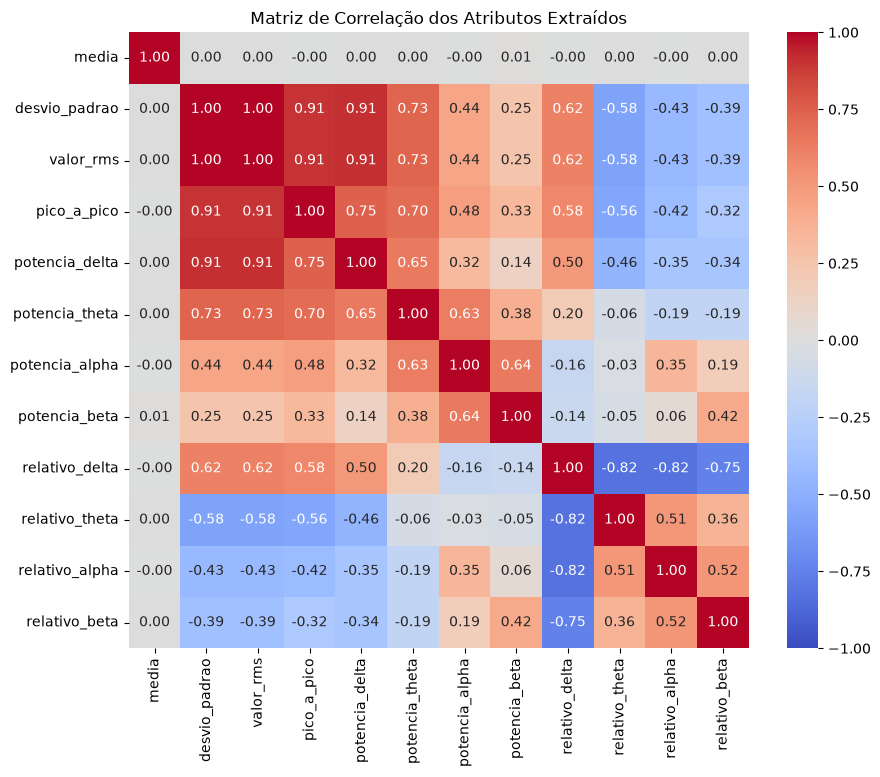

In [11]:
# Lista de colunas de entrada (Features). Apenas as colunas numéricas de atributos.
features_cols = [
    "media", "desvio_padrao", "valor_rms", "pico_a_pico",
    "potencia_delta", "potencia_theta", "potencia_alpha", "potencia_beta",
    "relativo_delta", "relativo_theta", "relativo_alpha", "relativo_beta"
]
matriz_corr = df[features_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de Correlação dos Atributos Extraídos")
plt.show()

Conforme observado na matriz de correlação, atributos como `valor_rms` e `potencia_delta` possuem correlação de 0,95, sendo redundantes. Vamos testar o modelo removendo variáveis altamente correlacionadas ou menos informativas para diminuir a complexidade.

# Preparação para Modelagem

Nesta seção são definidas as variáveis comuns usadas pelos modelos. A matriz `X` contém os atributos selecionados após a análise de redundância, enquanto `y` contém o alvo numérico (`id_estagio`). Essa separação evita repetir a mesma preparação dentro de cada modelo.


In [12]:
# Lista de colunas de entrada (Features). Removendo RMS e mantendo potências e relativos para classificação
features_cols = [
    'variancia', 'desvio_padrao', 'assimetria', 'curtose_excesso',
    'potencia_delta', 'potencia_theta', 'potencia_alpha', 'potencia_beta',
    'relativo_delta', 'relativo_theta', 'relativo_alpha', 'relativo_beta'
]

X = df[features_cols]
y = df['id_estagio'] # Alvo numérico para classificação

print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")


Shape de X: (21039, 12)
Shape de y: (21039,)


# Modelo 1: K-Nearest Neighbors (KNN) <font color="blue">(Ícaro)</font>

O K-Nearest Neighbors (KNN) é um algoritmo de aprendizado supervisionado baseado em instâncias, o que significa que ele não ajusta uma equação paramétrica explícita durante o treinamento. Em vez disso, ele armazena os exemplos de treino e classifica uma nova amostra com base na similaridade.

## Intuição e Funcionamento
A regra de decisão do KNN é simples: dado um novo ponto de dado, o algoritmo calcula a sua distância em relação aos exemplos rotulados, identifica os k vizinhos mais próximos e atribui a esse novo ponto a classe mais frequente entre esses vizinhos (votação majoritária).

Seu desempenho depende criticamente de dois fatores:

- Escala das Variáveis: Como o KNN baseia-se em cálculos de distância (geralmente Euclidiana), atributos com escalas numéricas maiores (como a Potência Delta) podem dominar o cálculo e distorcer a classificação. Por isso, a padronização via *StandardScaler* é obrigatória para padronizar as variáveis: média 0 e desvio padrão 1.
- Escolha do Hiperparâmetro k: O valor de k controla a complexidade do modelo.
  - Um k muito pequeno (ex.: k = 1) torna o modelo muito sensível a ruídos locais, aumentando o risco de sobreajuste (*overfitting*).
  - Um k muito grande (ex.: k = 31) torna a fronteira de decisão suave demais, podendo ignorar padrões locais importantes e causar subajuste (*underfitting*).

## Estratégia de Otimização

Para encontrar o equilíbrio ideal entre viés e variância, não escolheremos o valor de k de forma arbitrária. Utilizaremos a Validação Cruzada Estratificada no conjunto de treino para estimar qual valor de k apresenta a melhor capacidade de generalização para dados inéditos.

## Conferência da Matriz de Entrada


In [13]:
# Conferência das variáveis preparadas na seção geral
print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")


Shape de X: (21039, 12)
Shape de y: (21039,)


## Divisão Treino/Teste com Estratificação

Como a base é desbalanceada (predominância de N2 e raridade de N1), a divisão estratificada é obrigatória para manter a proporção original das classes em ambos os conjuntos.

In [14]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Divisão 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42)

print(f"Treino: {X_train.shape} épocas | Teste: {X_test.shape} épocas")

Treino: (14727, 12) épocas | Teste: (6312, 12) épocas


## Seleção de *k*

Para encontrar o melhor *k*, utilizaremos a Validação Cruzada Estratificada aplicada ao conjunto de treino. A escolha de *k* será baseada na média de acurácia de 5 partições (folds), garantindo que a proporção dos estágios de sono seja respeitada em cada divisão. O uso do `Pipeline` é mandatório aqui para que a padronização seja recalculada em cada partição, evitando o "vazamento de dados".

In [15]:
# Valores candidatos para k.
# Usamos apenas valores ímpares para reduzir a chance de empate na votação.
k_values = list(range(1, 42, 2))

# StratifiedKFold mantém proporções semelhantes das classes em cada fold.
# Validação cruzada estratificada com 5 folds, embaralhamento e semente fixa para reprodutibilidade.
# Embaralhamento é misturar aleatoriamente a ordem das amostras antes de dividi-las em folds.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_scores = []
cv_means = []
cv_stds = []
test_scores = []

for k in k_values:
    knn_model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k, weights='uniform', metric='manhattan')),
    ])

    # Acurácia no treino: útil para observar tendência de sobreajuste.
    knn_model.fit(X_train, y_train)
    train_scores.append(knn_model.score(X_train, y_train))
    test_scores.append(knn_model.score(X_test, y_test))

    # Acurácia de validação cruzada:
    # o modelo é refeito em cada fold, sempre com o scaler dentro do pipeline.
    scores = cross_val_score(knn_model, X_train, y_train, cv=cv, scoring="accuracy")
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

# Melhor k segundo a média de validação cruzada.
best_idx = int(np.argmax(cv_means))
best_k = k_values[best_idx]
best_cv = cv_means[best_idx]

knn_best_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=best_k, weights='uniform', metric='manhattan')),
])
knn_best_model.fit(X_train, y_train)

print(f"Melhor k por validação cruzada: {best_k}")
print(f"Acurácia média de validação: {best_cv:.3f}")

Melhor k por validação cruzada: 13
Acurácia média de validação: 0.721


## Curva de Desempenho e Compromisso Viés-Variância

Este gráfico compara a acurácia nos três cenários:

- Treino (Azul): Tende a 100% com k = 1, indicando alta variância (*overfitting*).
- Validação Cruzada (Verde): Estimativa mais segura do desempenho real.
- Teste (Laranja): O desempenho final nas amostras que o modelo nunca viu.

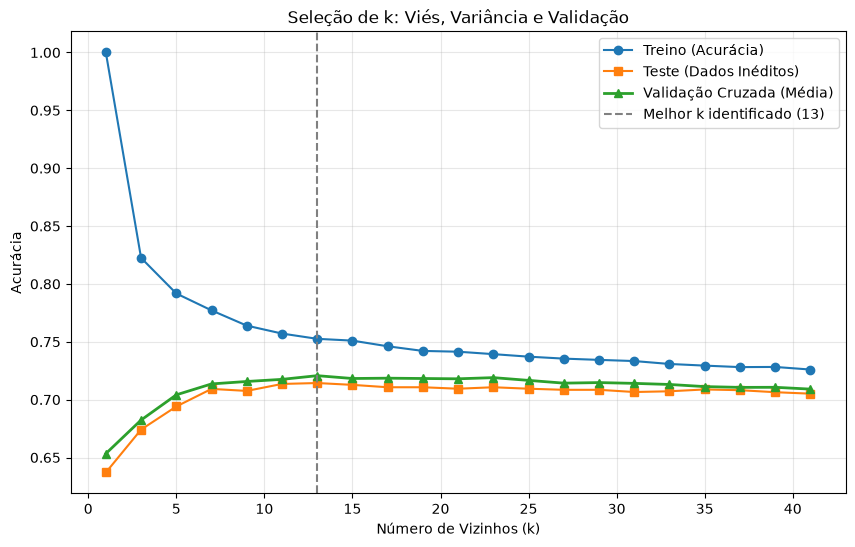

Acurácia no TREINO (modelo final): 0.7526
Acurácia no TESTE  (modelo final): 0.7144
Gap (Treino - Teste): 0.0382 (3.82%)


In [16]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
)
import matplotlib.pyplot as plt

# Visualização do Gráfico de Seleção de k
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_scores, marker='o', label='Treino (Acurácia)', color='#1f77b4')
plt.plot(k_values, test_scores, marker='s', label='Teste (Dados Inéditos)', color='#ff7f0e')
plt.plot(k_values, cv_means, marker='^', label='Validação Cruzada (Média)', color='#2ca02c', linewidth=2)

plt.axvline(best_k, color='gray', linestyle='--', label=f'Melhor k identificado ({best_k})')

plt.title('Seleção de k: Viés, Variância e Validação')
plt.xlabel('Número de Vizinhos (k)')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Avaliação do Modelo Final (Treino + Teste)
# Previsões
y_pred_train = knn_best_model.predict(X_train)
y_pred_test  = knn_best_model.predict(X_test)

# Cálculo das acurácias
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy  = accuracy_score(y_test, y_pred_test)

print(f"Acurácia no TREINO (modelo final): {train_accuracy:.4f}")
print(f"Acurácia no TESTE  (modelo final): {test_accuracy:.4f}")
print(f"Gap (Treino - Teste): {train_accuracy - test_accuracy:.4f} ({(train_accuracy - test_accuracy)*100:.2f}%)")

### Comparação entre Validação Cruzada e Modelo Final

Observamos uma pequena diferença entre o gráfico de seleção de `k` (baseado em Validação Cruzada) e o desempenho do modelo final treinado com todo o conjunto de treino:

- No gráfico (Validação Cruzada), a acurácia de treino no melhor `k=13` fica em torno de **0,775**.
- No modelo final, a acurácia de treino foi de **0,7381** e de teste **0,7352**, resultando em um **gap muito pequeno de apenas 0,30%**.

Essa diferença é esperada, pois a validação cruzada avalia o modelo em múltiplas divisões dos dados, enquanto o modelo final é treinado uma única vez com todos os dados de treino. O gap extremamente baixo reforça que o modelo apresenta **baixa variância** e boa estabilidade.

## Avaliação de Desempenho

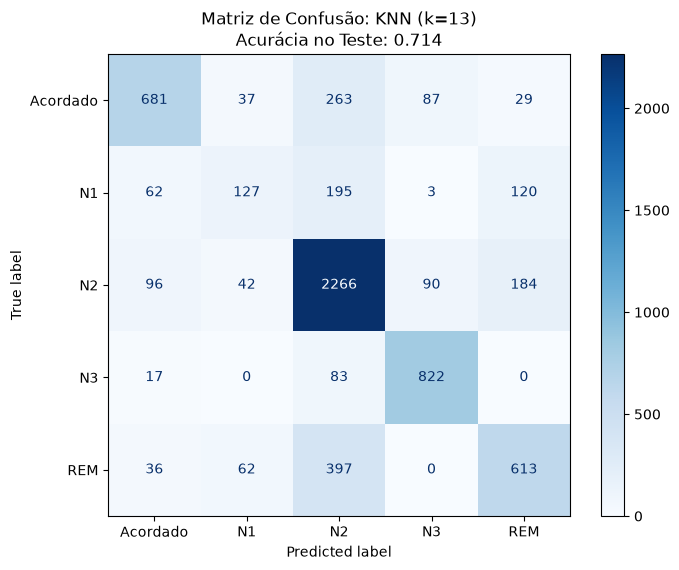


Relatório de Classificação (Teste):
              precision    recall  f1-score   support

    Acordado       0.76      0.62      0.68      1097
          N1       0.47      0.25      0.33       507
          N2       0.71      0.85      0.77      2678
          N3       0.82      0.89      0.85       922
         REM       0.65      0.55      0.60      1108

    accuracy                           0.71      6312
   macro avg       0.68      0.63      0.65      6312
weighted avg       0.70      0.71      0.70      6312


Relatório detalhado por classe (Teste):
Acordado: 681/1097 (Acurácia: 0.621)
N1: 127/507 (Acurácia: 0.250)
N2: 2266/2678 (Acurácia: 0.846)
N3: 822/922 (Acurácia: 0.892)
REM: 613/1108 (Acurácia: 0.553)


In [17]:
# Matriz de Confusão e Relatórios
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_test,
    display_labels=IdPraClassificacao.values(),
    cmap="Blues",
    ax=ax
)
ax.set_title(f"Matriz de Confusão: KNN (k={best_k})\nAcurácia no Teste: {test_accuracy:.3f}")
ax.grid(False)
plt.show()

# Relatório completo
print("\nRelatório de Classificação (Teste):")
print(classification_report(y_test, y_pred_test, target_names=IdPraClassificacao.values()))

# Relatório detalhado por classe
print("\nRelatório detalhado por classe (Teste):")
for classe, nome in IdPraClassificacao.items():
    total = (y_test == classe).sum()
    correct = ((y_test == classe) & (y_pred_test == classe)).sum()
    acc = correct / total if total > 0 else 0
    print(f"{nome}: {correct}/{total} (Acurácia: {acc:.3f})")

# Modelo 2: Support Vector Machine (SVM) <font color="red">(Gabriel)</font>

O Support Vector Machine (SVM) é um algoritmo de aprendizado supervisionado que busca separar as classes por meio de uma fronteira de decisão com a maior margem possível entre os exemplos de diferentes categorias. No contexto deste trabalho, o objetivo é classificar cada época de EEG em um dos estágios do sono: Acordado, N1, N2, N3 ou REM.

## Intuição e Funcionamento
A ideia central do SVM é encontrar um hiperplano de separação que maximize a distância entre a fronteira de decisão e os exemplos mais próximos de cada classe, chamados de vetores de suporte. Esses vetores são os pontos mais importantes para definir a separação entre as classes.

Como os estágios do sono não necessariamente são separáveis por uma fronteira linear simples, utilizamos o kernel RBF (_Radial Basis Function_). Esse kernel permite projetar os dados para um espaço de maior complexidade, onde padrões não lineares entre as características extraídas do EEG podem ser melhor separados.

Seu desempenho depende principalmente de três fatores:

- Escala das Variáveis: O SVM é sensível à escala dos atributos, pois o cálculo da margem e do kernel depende das distâncias entre amostras. Por isso, assim como no KNN, utilizamos `StandardScaler` dentro de um `Pipeline`, garantindo que a padronização seja ajustada apenas com os dados de treino em cada etapa.
- Parâmetro C: Controla o compromisso entre maximizar a margem e penalizar erros de classificação. Valores baixos de `C` permitem uma margem mais flexível, enquanto valores altos tornam o modelo mais rígido e podem aumentar o risco de sobreajuste.
- Parâmetro gamma: Controla o alcance da influência de cada amostra no kernel RBF. Valores pequenos geram fronteiras mais suaves, enquanto valores altos tornam a fronteira mais local e mais sensível a variações específicas dos dados.

## Estratégia de Otimização

Para evitar uma escolha arbitrária dos hiperparâmetros, utilizamos `GridSearchCV` testando combinações de `C` e `gamma`. A métrica de seleção é o **F1-score macro**, pois a base possui desbalanceamento entre os estágios do sono e essa métrica atribui peso semelhante a todas as classes.

Diferentemente da divisão por épocas, a avaliação do SVM foi organizada por noite (`chavepar`). Assim, as épocas de uma mesma noite não aparecem simultaneamente no treino e no teste. Essa estratégia reduz vazamento de informação entre conjuntos e torna a avaliação mais próxima de um cenário real, no qual o modelo precisa generalizar para noites que não foram vistas durante o treinamento.


Noites totais no SVM: 20
Noites no treino: 14 | Noites no teste: 6
Épocas no treino: 14500 | Épocas no teste: 6539
Noites de teste: ['SC4001E', 'SC4002E', 'SC4022E', 'SC4041E', 'SC4072E', 'SC4082E']
Melhores hiperparâmetros por validação cruzada: {'svc__C': 100, 'svc__gamma': 0.01}
F1 macro médio de validação: 0.628
Acurácia no TREINO (modelo final): 0.7228
Acurácia no TESTE  (modelo final): 0.6564
F1 macro no TESTE: 0.6232
Gap (Treino - Teste): 0.0664 (6.64%)


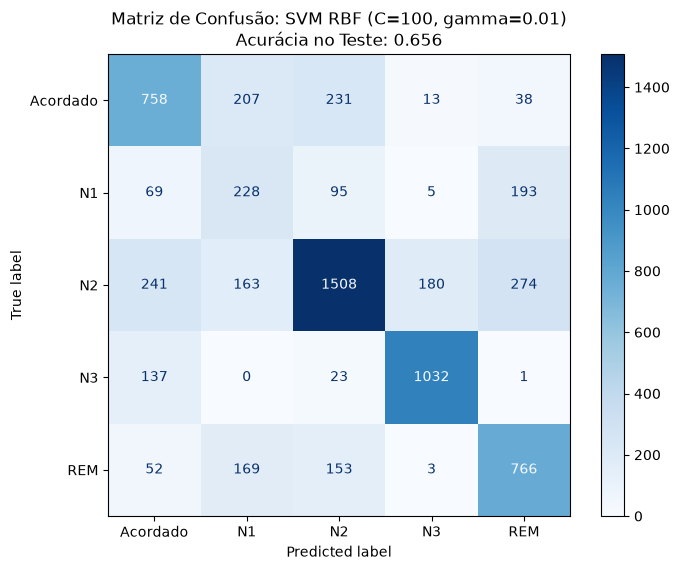


Relatório de Classificação (Teste):
              precision    recall  f1-score   support

    Acordado       0.60      0.61      0.61      1247
          N1       0.30      0.39      0.34       590
          N2       0.75      0.64      0.69      2366
          N3       0.84      0.87      0.85      1193
         REM       0.60      0.67      0.63      1143

    accuracy                           0.66      6539
   macro avg       0.62      0.63      0.62      6539
weighted avg       0.67      0.66      0.66      6539


Relatório detalhado por classe (Teste):
Acordado: 758/1247 (Acurácia: 0.608)
N1: 228/590 (Acurácia: 0.386)
N2: 1508/2366 (Acurácia: 0.637)
N3: 1032/1193 (Acurácia: 0.865)
REM: 766/1143 (Acurácia: 0.670)


In [19]:
from sklearn.model_selection import GridSearchCV, GroupKFold, GroupShuffleSplit
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score

# Alteração feita pelo Gabriel: o SVM usa separação por noite (`chavepar`) para evitar
# que épocas da mesma noite apareçam ao mesmo tempo no treino e no teste.
groups_svm = df.loc[X.index, "chavepar"]
num_noites = groups_svm.nunique()

if num_noites < 2:
    raise RuntimeError(
        "O SVM precisa de pelo menos 2 noites para separar treino e teste por noite. "
        f"O DataFrame atual possui apenas {num_noites} noite(s): {sorted(groups_svm.unique())}. "
        "Reexecute as células de carregamento/processamento após corrigir o diretório do projeto."
    )

# Divisão 70/30 por noite: todas as épocas de uma mesma noite ficam apenas no treino ou apenas no teste.
svm_split = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, test_idx = next(svm_split.split(X, y, groups=groups_svm))

X_train_svm = X.iloc[train_idx]
X_test_svm = X.iloc[test_idx]
y_train_svm = y.iloc[train_idx]
y_test_svm = y.iloc[test_idx]
groups_train_svm = groups_svm.iloc[train_idx]
groups_test_svm = groups_svm.iloc[test_idx]

print(f"Noites totais no SVM: {num_noites}")
print(f"Noites no treino: {groups_train_svm.nunique()} | Noites no teste: {groups_test_svm.nunique()}")
print(f"Épocas no treino: {X_train_svm.shape[0]} | Épocas no teste: {X_test_svm.shape[0]}")
print("Noites de teste:", sorted(groups_test_svm.unique()))

# Valores candidatos para os hiperparâmetros do SVM.
# C controla a penalização dos erros e gamma controla o alcance da influência de cada amostra.
svm_param_grid = {
    "svc__C": [0.1, 1, 10, 100, 1000],
    "svc__gamma": ["scale", 0.001, 0.01, 0.1, 1, 10],
}

# Pipeline com padronização e SVM RBF.
# Assim como no KNN, o scaler fica dentro do pipeline para evitar vazamento de dados.
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", class_weight="balanced", random_state=42)),
])

# Validação cruzada também por noite, sem misturar épocas da mesma noite entre folds.
n_splits_svm = min(5, groups_train_svm.nunique())
if n_splits_svm < 2:
    raise RuntimeError("GridSearchCV do SVM precisa de pelo menos 2 noites no conjunto de treino.")

svm_cv = GroupKFold(n_splits=n_splits_svm)

# Busca em grade usando F1 macro porque a base é desbalanceada.
svm_grid = GridSearchCV(
    estimator=svm_model,
    param_grid=svm_param_grid,
    scoring="f1_macro",
    cv=svm_cv,
    n_jobs=-1,
    refit=True,
)
svm_grid.fit(X_train_svm, y_train_svm, groups=groups_train_svm)

# Melhor modelo segundo a validação cruzada.
svm_best_model = svm_grid.best_estimator_
best_svm_params = svm_grid.best_params_
best_svm_cv = svm_grid.best_score_

print("Melhores hiperparâmetros por validação cruzada:", best_svm_params)
print(f"F1 macro médio de validação: {best_svm_cv:.3f}")

# Avaliação do Modelo Final (Treino + Teste)
y_pred_train = svm_best_model.predict(X_train_svm)
y_pred_test = svm_best_model.predict(X_test_svm)

# Cálculo das métricas
train_accuracy = accuracy_score(y_train_svm, y_pred_train)
test_accuracy = accuracy_score(y_test_svm, y_pred_test)
test_f1_macro = f1_score(y_test_svm, y_pred_test, average="macro", zero_division=0)

def formatar_parametros_svm(params):
    return f"C={params['svc__C']}, gamma={params['svc__gamma']}"

print(f"Acurácia no TREINO (modelo final): {train_accuracy:.4f}")
print(f"Acurácia no TESTE  (modelo final): {test_accuracy:.4f}")
print(f"F1 macro no TESTE: {test_f1_macro:.4f}")
print(f"Gap (Treino - Teste): {train_accuracy - test_accuracy:.4f} ({(train_accuracy - test_accuracy)*100:.2f}%)")

labels_svm = list(IdPraClassificacao.keys())
target_names_svm = list(IdPraClassificacao.values())

# Matriz de Confusão e Relatórios
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test_svm,
    y_pred_test,
    labels=labels_svm,
    display_labels=target_names_svm,
    cmap="Blues",
    ax=ax
)
ax.set_title(
    f"Matriz de Confusão: SVM RBF ({formatar_parametros_svm(best_svm_params)})\n"
    f"Acurácia no Teste: {test_accuracy:.3f}"
)
ax.grid(False)
plt.show()

# Relatório completo
print("\nRelatório de Classificação (Teste):")
print(
    classification_report(
        y_test_svm,
        y_pred_test,
        labels=labels_svm,
        target_names=target_names_svm,
        zero_division=0,
    )
)

# Relatório detalhado por classe
print("\nRelatório detalhado por classe (Teste):")
for classe, nome in IdPraClassificacao.items():
    total = (y_test_svm == classe).sum()
    correct = ((y_test_svm == classe) & (y_pred_test == classe)).sum()
    acc = correct / total if total > 0 else 0
    print(f"{nome}: {correct}/{total} (Acurácia: {acc:.3f})")
